In [1]:
#basic imports
import numpy as np
import pandas as pd
import opendatasets as od
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random

#torch
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
import  torchvision.transforms.v2 as transform
from PIL import Image

In [2]:
data_dir = Path(
"C:/Users/Global Lecturer/Documents/Personal/Data Science/Deep-learning-pytorch/personal-machine-learning-note/dataset" 
)
data_dir.mkdir(parents=True, exist_ok=True)


In [3]:
train = datasets.FashionMNIST(
    data_dir,
    train=True,
    download=True
)

test = datasets.FashionMNIST(
    data_dir,
    train=False,
    download=True
)

In [4]:
os.listdir(data_dir/"Fashionmnist"/"raw")



['t10k-images-idx3-ubyte',
 't10k-images-idx3-ubyte.gz',
 't10k-labels-idx1-ubyte',
 't10k-labels-idx1-ubyte.gz',
 'train-images-idx3-ubyte',
 'train-images-idx3-ubyte.gz',
 'train-labels-idx1-ubyte',
 'train-labels-idx1-ubyte.gz']

In [5]:
print(train[0])

(<PIL.Image.Image image mode=L size=28x28 at 0x259AFDB5FF0>, 9)


In [6]:
### Write Dataset Classs
class FashionMnistDataset(Dataset):
    def __init__(self, data, transform = None):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        image, label = self.data[index]
        
        if self.transform:
            image = self.transform(image)
        return image, label
            
        

In [7]:
train_transform = transform.Compose([
    transform.RandomHorizontalFlip(p=0.5),
    transform.ToTensor(),
    transform.Normalize(mean=[0.1307], std=[0.3081]),
    transform.ToDtype(torch.float32, scale=True),
    
])

test_transform = transform.Compose([
    transform.ToTensor(),
    transform.Normalize(mean=[0.1307], std=[0.3081]),
    transform.ToDtype(torch.float32, scale=True),
    
])

c:\Users\Global Lecturer\miniconda3\envs\mlenv\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [8]:
train_dataset = FashionMnistDataset(train, transform=train_transform)
test_dataset = FashionMnistDataset(test, transform=test_transform)

### visualizing one image and random images

Text(0.5, 1.0, 'Ankle boot')

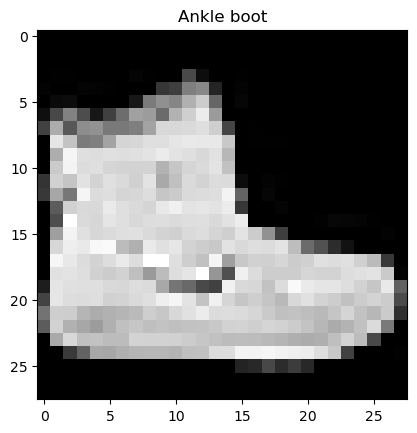

In [9]:
img, label = train_dataset[0]
img.shape
plt.imshow(img.permute(1,2,0), cmap="gray")
plt.title(train.classes[label])

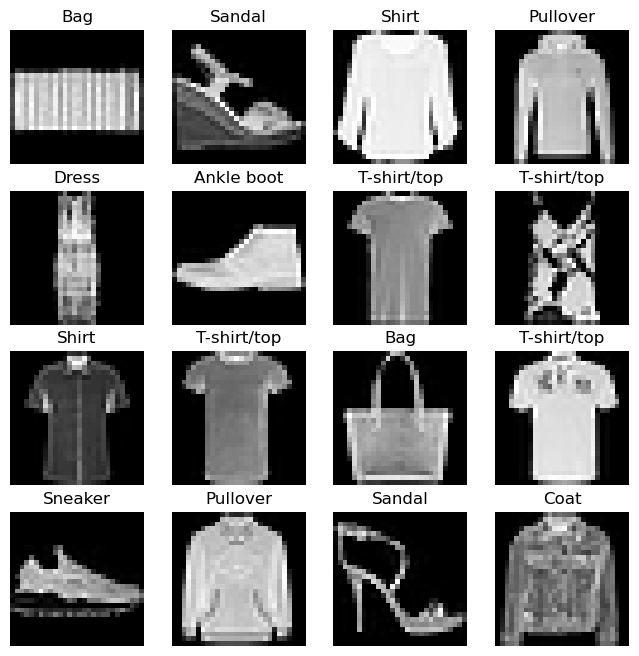

In [10]:
nrows=4
ncols = 4
plt.figure(figsize=(8, 8))
for i in range(1, nrows*ncols+1):
    random_index = random.choice(list(range(len(train_dataset))))
    img, label = train_dataset[random_index]
    plt.subplot(nrows, ncols, i)
    plt.imshow(img.permute(1,2, 0), cmap="gray")
    plt.title(train.classes[label])
    plt.axis("off")

In [11]:
BATCHSIZE = 32
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCHSIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCHSIZE,
    shuffle = False
)

In [12]:
images, labels = next(iter(train_loader))
images.shape, label

(torch.Size([32, 1, 28, 28]), 4)

In [13]:

class MnistNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        #14x14 images
          
        self.block2 = nn.Sequential(
             nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
             nn.BatchNorm2d(32),
             nn.ReLU(),
             nn.MaxPool2d(kernel_size=2, stride=2)
                )
        self.adaptivepool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(in_features=1568, out_features=512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=512, out_features=num_classes),
            
        )
        
    def forward(self, input):
        x = self.block1(input)
        x = self.block2(x)
        x = self.adaptivepool(x)
        x = torch.flatten(x, 1)
        x= self.classifier(x)
        return x
        

In [14]:
len(train.classes)

10

In [15]:
from torchmetrics.classification import MulticlassAccuracy


In [ ]:
def Evaluate_model_func(model, dataloader, metrics, device, loss_func,):
    """ returns (test loss , test accuracy)"""
    metrics.reset()
    model.eval()
    test_loss = 0.0
    with torch.inference_mode():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            y_logits = model(x)
            y_prob = torch.softmax(y_logits, dim=1)
            y_pred = torch.argmax(y_prob, dim=1)
            loss = loss_func(y_logits, y)
            metrics.update(y_pred, y)
            test_loss += loss.item() 
        test_loss /= len(dataloader)
        return test_loss, metrics.compute().item()
        


def Train_model_func(model, train_loader, test_loader, loss_func, optimizer, device, epochs, metrics):
    results= {
        "train_loss": [],
        "train_acc" : [],
        "test_loss": [],
        "test_acc": [],
    }
    
    for epoch in range(epochs):
        metrics.reset()
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x,y = x.to(device), y.to(device)
            y_logits = model(x)
            y_prob = torch.softmax(y_logits, dim=1)
            y_pred = torch.argmax(y_prob, dim = 1)
            loss = loss_func(y_logits, y)
            total_loss += loss.item()
            metrics.update(y_pred, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss /= len(train_loader)
        train_acc = metrics.compute().item()
        test_loss, test_acc = Evaluate_model_func(model=model, dataloader=test_loader, metrics=metrics, device=device, loss_func=loss_func)
        results["train_loss"].append(total_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        
        print(
            f"epoch : {epoch+1}/{epochs} "
            f"train_loss:{total_loss} "
            f"train acc:{train_acc} "
            f"test_loss:{test_loss} "
            f"test acc:{test_acc} "
            )
    return results

In [17]:
def initialize_weight(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(module.weight, mode="fan_in", nonlinearity="relu")
        if module.bias is not None:
            nn.init.constant_(module.bias, 0)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.constant_(module.weight, 1)
        nn.init.constant_(module.bias, 0)
            
            
            
    

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MnistNet(in_channels=1, num_classes=10).to(device)
model.apply(initialize_weight)

MnistNet(
  (block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptivepool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Sequential(
    (0): Linear(in_features=1568, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [19]:
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-2, weight_decay=1e-4)
epochs = 10
metrics = MulticlassAccuracy(num_classes=10).to(device)
results = Train_model_func(model, train_loader, test_loader, loss_func, optimizer, device, epochs,metrics )

epoch : 1/10 train_loss:0.7242771986405054 train acc:0.7745667099952698 test_loss:0.3956462060110257 test acc:0.8513999581336975 
epoch : 2/10 train_loss:0.4356493730346362 train acc:0.8451834321022034 test_loss:0.35402195473400927 test acc:0.8723000288009644 
epoch : 3/10 train_loss:0.40843469814062117 train acc:0.8559166789054871 test_loss:0.3401972568763521 test acc:0.8790000081062317 
epoch : 4/10 train_loss:0.39544487725893657 train acc:0.8596667647361755 test_loss:0.33347792278963345 test acc:0.8827000260353088 
epoch : 5/10 train_loss:0.3853197276433309 train acc:0.8642333745956421 test_loss:0.3214157255241475 test acc:0.8796999454498291 
epoch : 6/10 train_loss:0.37764945706526437 train acc:0.8661166429519653 test_loss:0.32504593536329157 test acc:0.8868999481201172 
epoch : 7/10 train_loss:0.37058449998895326 train acc:0.8694166541099548 test_loss:0.32854164710131506 test acc:0.8856000304222107 
epoch : 8/10 train_loss:0.36902312940259774 train acc:0.8697167038917542 test_loss

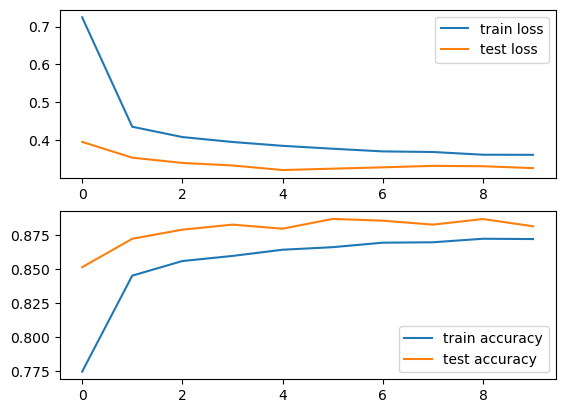

In [22]:
epoch_range = range(len(results["train_acc"]))
fig, ax = plt.subplots(2, 1)
ax = ax.flatten()
ax[0].plot(epoch_range, results["train_loss"], label="train loss")
ax[0].plot(epoch_range, results["test_loss"], label="test loss")
ax[0].legend()
ax[1].plot(epoch_range, results["train_acc"], label="train accuracy")
ax[1].plot(epoch_range, results["test_acc"], label="test accuracy")
ax[1].legend()

### Notes
- The model looks pretty good, the model its quite heavy for Fashion mnist dataset since 1 channel images are not complex yet it didnt overfit
- Due to the regularization techniques 

In [23]:
torch.save(model.state_dict(), "fashion_mnist.pth")
model.state_dict()

OrderedDict([('block1.0.weight',
              tensor([[[[-4.9111, -3.9742, -2.6300],
                        [ 0.5167, -1.1962,  0.2189],
                        [-0.3230,  0.3126,  1.2974]]],
              
              
                      [[[-1.3079,  1.1206,  1.1122],
                        [-2.4035, -0.5360,  1.9970],
                        [-1.4405,  0.3160,  0.8911]]],
              
              
                      [[[-0.4205, -2.7578, -1.7067],
                        [-0.2464, -2.9211, -3.3161],
                        [ 1.4872, -0.5397, -0.0299]]],
              
              
                      [[[-0.2315, -0.4816, -0.8803],
                        [-0.7193,  0.6862, -0.2920],
                        [-0.3110, -0.7620,  0.3124]]],
              
              
                      [[[ 2.2006,  2.2973,  1.1384],
                        [ 0.4822,  1.7674,  0.8291],
                        [-1.1515, -1.4894, -0.9395]]],
              
              
            

In [36]:
train_data= datasets.MNIST(
     data_dir,
    train=True,
    download=True
)

test_data = datasets.MNIST(
        data_dir,
        train=False,
        download=True
)

Text(0.5, 1.0, '5')

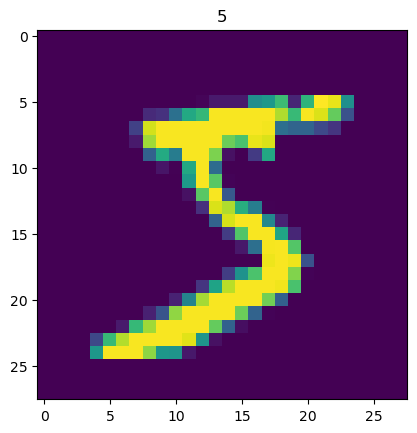

In [37]:
## Visualize samples

img, label = train_data[0]
plt.imshow(img)
plt.title(f"{label}")

In [40]:
class DigitMnistDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        img, label = self.data[index]
        
        if transform is not None:
            img = self.transform(img)
        return img, label 
        

In [41]:
train_digit_mnist = DigitMnistDataset(data=train_data, transform=train_transform)
test_digit_mnist = DigitMnistDataset(test_data, transform=test_transform)

In [42]:
train_digit_Loader = DataLoader(train_digit_mnist, batch_size=BATCHSIZE, shuffle=True)
test_digit_loader = DataLoader(test_digit_mnist, batch_size=BATCHSIZE, shuffle=False)

In [43]:
transfer_model = MnistNet(in_channels=1, num_classes=10)
transfer_model.load_state_dict(torch.load("fashion_mnist.pth"))
transfer_model = transfer_model.to(device)

C:\Users\Global Lecturer\AppData\Local\Temp\ipykernel_3364\3938055675.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transfer_model.load_state_dict(torch.load("fashion_

##### Making quick inferenced on untrained model before transfer learning

In [44]:
test_loss, test_acc = Evaluate_model_func(model, test_digit_loader, metrics, device, loss_func)

In [45]:
print(f'test acc: {test_acc}')


test acc: 0.10892610251903534


#### The Accuracy of 0.109 is not surprising 
- because model doesnot know digit mnist
- Lets see accuracy after transfer learning

In [48]:
### Freezing Convolutional layers (feature extraction)
for name,parameters in transfer_model.named_parameters():
    if "classifier" not in name:
        parameters.requires_grad=False
        
        

In [50]:
#sanity check
for name, param in transfer_model.named_parameters():
    print(name, param.requires_grad)

block1.0.weight False
block1.0.bias False
block1.1.weight False
block1.1.bias False
block2.0.weight False
block2.0.bias False
block2.1.weight False
block2.1.bias False
classifier.0.weight True
classifier.0.bias True
classifier.3.weight True
classifier.3.bias True
